In [1]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
import scipy as sp
from matplotlib import pyplot as plt
import time
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Uni/ImageProcessing')
rootfolder = 'Colab Students - Assignments/data'

Mounted at /content/drive


Useful function for plot the dictionary

In [3]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Set all the parameters for the anomaly detection

In [4]:
# patch size (tha patch is square)
p = 15

# number of patches in the training set for dictionary learning
npatch_dictionary = 10000

# number of patches to estimate the confidence region
npatch_region = 10000

# parameters for the dictionary learning using the KSVD
niter_dl = 10
natom = int(np.round(p**2*1.5))
L = 4
M = p**2

# regularization parameters for the l1 sparse coding
lmbda = 0.18

Construct the training and validation sets
------------------------------------------

In [5]:
# load the training image and rescale it in [0,1]
img = imread(f'{rootfolder}/img_normal.png') / 255
imsz = img.shape
S = np.zeros((p**2, npatch_dictionary))
V = np.zeros((p**2, npatch_region))

# extract random patches from the image and store them in a matrices S, V
for i in range(npatch_dictionary):
    r = np.random.randint(0, imsz[0] - p)
    c = np.random.randint(0, imsz[1] - p)
    S[:, i] = img[r:r+p, c:c+p].flatten()

for i in range(npatch_region):
    r = np.random.randint(0, imsz[0] - p)
    c = np.random.randint(0, imsz[1] - p)
    V[:, i] = img[r:r+p, c:c+p].flatten()

Dictionary Learning
-------------------
Perform preprocessing on the patches in $S$

In [6]:
# PREPROCESSING: exclude black patches from S
v = np.median(S, axis=0)
S = S[:,v > 0.06]

In [7]:
# PREPROCESSING: remove the mean from each patch
S = S - np.mean(S, axis=0)

Perform dictionary learning via KSVD or MOD

In [8]:
try:
    D = loadmat(f'{rootfolder}/data/dict_anom_det.mat')['D']
except FileNotFoundError:
    D = np.random.randn(p**2, natom)
    D = D / np.linalg.norm(D, axis=0)

In [9]:
def ksvd(S, M, N, max_iter, npatch, L, print_time=True):

    # intialize the dictionary
    D = np.random.randn(M, N)

    # normalize each column of D (zero mean and unit norm)
    # UPDATE D
    D = D - np.mean(D, axis=0)
    D = D / np.linalg.norm(D, axis=0)

    # initialize the coefficient matrix
    X = np.zeros((N, npatch))

    # Main KSVD loop
    for iter in range(max_iter):
        time_start = time.time()

        # Sparse coding step
        # perform the sparse coding via OMP of all the columns of S
        for n in range(npatch):
            X[:, n] = OMP(S[:, n], D, L, tau=0)

        # Dictionary update step
        # iterate over the columns of D
        for j in range(N):
            # find which signals uses the j-th atom in the sparse coding
            omega = np.nonzero(X[j, :])[0]

            if len(omega) == 0:
                # if the atom is never used then ignore or substitute it with a random vector
                d_new = np.random.randn(M)
                d_new = d_new - np.mean(d_new)
                D[:, j] = d_new / np.linalg.norm(d_new)
            else:
                # compute the residual matrix E, ignoring the j-th atom
                E = S - np.dot(D, X) + np.outer(D[:, j], X[j, :])

                # restrict E to the columns indicated by omega
                Eomega = E[:, omega]

                # Compute the best rank-1 approximation
                U, Sigma, V = np.linalg.svd(Eomega, full_matrices=False)

                # update the dictionary
                D[:, j] = U[:, 0]

                # update the coefficient matrix
                X[j, omega] = Sigma[0] * V[0, :]

        time_end = time.time()
        if print_time:
            print(f'Iteration {iter} runtime: {time_end-time_start}')

    return D

In [10]:
#D = ksvd(S, M, natom, max_iter=niter_dl, npatch=S.shape[1], L=L)

# or load a precomputed dictionary
D = loadmat(f'{rootfolder}/dict_anom_det.mat')['D']

Show the learned dictionary

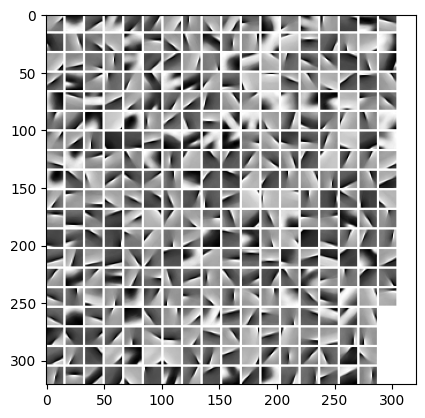

In [11]:
img_dict = get_dictionary_img(D)
plt.imshow(img_dict, cmap='gray')
plt.show()

## Confidence region estimation / density estimation

In [12]:
# PREPROCESSING: exclude black patches
v = np.median(V, axis=0)
V = V[:,v > 0.06]

In [13]:
# PREPROCESSING: remove the mean from each patch
V = V - np.mean(V, axis=0)

In [14]:
def OMP(s, D, L, tau, maxiter = 10000):
  M,N = D.shape
  x = np.zeros(N)
  i = 0
  r = s.copy()
  w = []
  while np.linalg.norm(r) > tau and len(w) < L and i < maxiter:

        # Match
        epsilon = np.abs(np.dot(D.T, r))
        jstar = np.argmax(epsilon)

        # Update w
        if jstar not in w:
            w.append(jstar)

        # Least squares update
        D_omega = D[:, w]
        x_omega, _, _, _ = np.linalg.lstsq(D_omega, s, rcond=None)

        #sparse vector and residual
        x = np.zeros(N)
        x[w] = x_omega
        r = s - np.dot(D, x)

        i += 1

  return x

In [15]:
# sparse coding of each patch in V
X = np.zeros((natom, npatch_region))
for i in range(V.shape[1]):
    X[:, i] = OMP(V[:, i], D, L, tau=0.1)



In [16]:
# computing the anomaly indicators (l1 norm, reconstruction error) for each
# patch in V

A = np.zeros((2, V.shape[1]))

for i in range(V.shape[1]):
    A[0, i] = np.linalg.norm(V[:, i] - np.dot(D, X[:, i]), ord=2)
    A[1, i] = np.linalg.norm(X[:, i], ord=1)

mu = np.mean(A, axis=1)
Sigma = np.cov(A)


In [17]:
# estimation of the threshold that gives the desired false positive rate
# using the patches in V

FPR_target = 0.01

inv_Sigma = np.linalg.inv(Sigma)
mahal_dist = np.zeros(A.shape[1])

# compute the Mahalanobis distance for each indicator vector in A
for i in range(A.shape[1]):
    diff = A[:, i] - mu
    mahal_dist[i] = np.sqrt(np.dot(diff.T, np.dot(inv_Sigma, diff)))

# set the threshold
# Use the actual number of samples in A instead of the constant npatch_region
threshold = np.percentile(mahal_dist, 100 * (1 - FPR_target))

## Test phase

In [18]:
# load the test image
img_test = imread(f'{rootfolder}/img_anom.png') / 255

imsz = img_test.shape

STEP = 4

# initialize the estimated image
heatmap = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

In [19]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = img_test[i:i+p, j:j+p].flatten()

        # if the median of s is to small set the anomaly score to 0:
        if np.median(s) <= 0.06:
            score = 0
        else:
            # subratct the mean to the patch
            s = s - np.mean(s)

            # perform the sparse coding
            x = OMP(s, D, L, tau=0.1)

            # compute the anomaly indicators vector
            a = np.zeros(2)
            a[0] = np.linalg.norm(s - np.dot(D, x), ord=2)
            a[1] = np.linalg.norm(x, ord=1)

            # compute the anomaly score
            diff = a - mu
            score = np.sqrt(np.dot(diff.T, np.dot(inv_Sigma, diff)))

        # update the heatmap
        heatmap[i:i+p, j:j+p] += score

        # update the weight matrix
        weights[i:i+p, j:j+p] += 1.0



In [20]:
# normalize the heatmap
heatmap = heatmap / (weights + 1e-8)

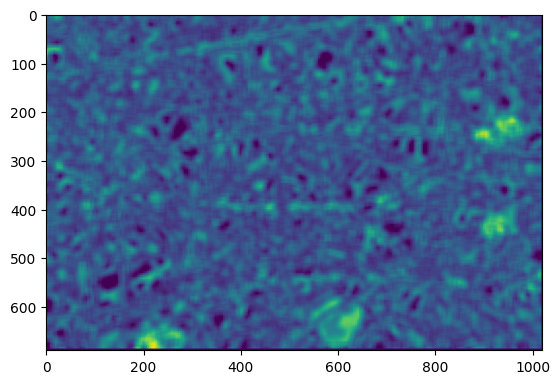

In [21]:
# plot the heatmap
plt.imshow(heatmap)

In [22]:
# build the detection mask, that has the same size of the test image
# each pixel in the mask has value 1 if the corresponding patch has been
# detected as anomalous, otherwise it has value 0
mask = (heatmap > threshold).astype(float)


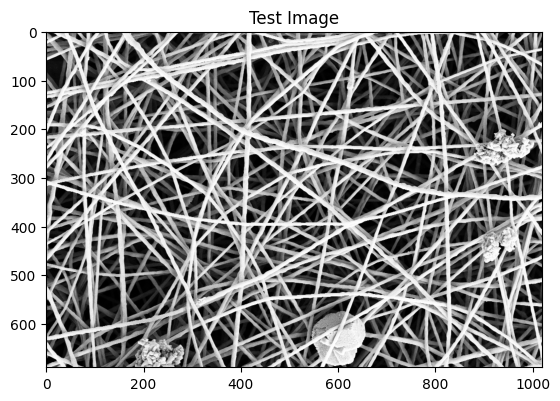

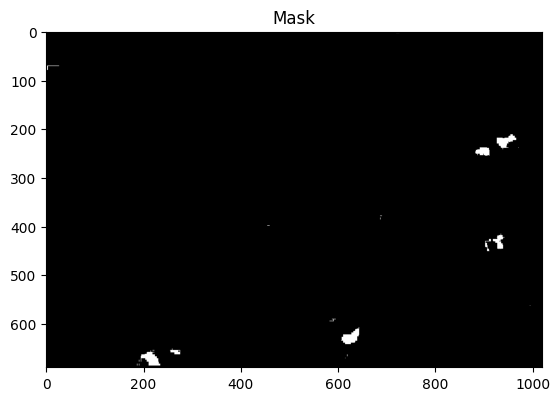

In [23]:
## show the results
plt.figure(3), plt.imshow(img_test, cmap='gray'), plt.title('Test Image')
plt.figure(4), plt.imshow(mask, cmap='gray'), plt.title('Mask')
plt.show()

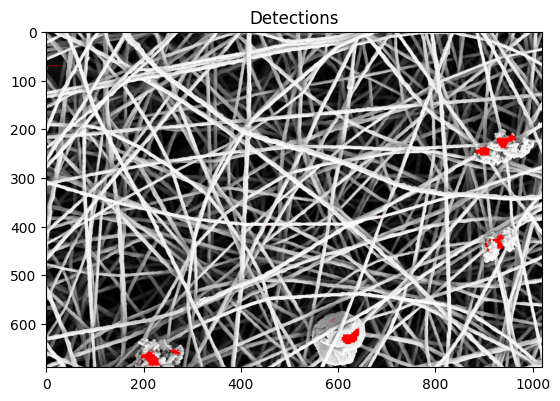

In [24]:
# combine the mask and the test image
img_color = np.zeros([img_test.shape[0], img_test.shape[1], 3])
img_temp = img_test.copy()
img_temp[mask > 0] = 1
img_color[:,:,0] = img_temp
img_temp = img_test.copy()
img_temp[mask > 0] = 0
img_color[:,:,1] = img_temp
img_temp = img_test.copy()
img_temp[mask > 0] = 0
img_color[:,:,2] = img_temp

plt.figure(5), plt.imshow(img_color), plt.title('Detections')
plt.show()